# Actividad N°3 - Mi primer EDA

Análisis exploratorio del dataset `clientes.csv`.

**Pasos:**
1. Un primer vistazo: resumen estadístico de las variables numéricas.
2. Manipulación de datos: filtro de clientes de alto valor y media de ingresos por estado civil.
3. Exploración visual: histograma de edad y scatter de ingresos vs monto de compra.

## Importación de librerías y carga del dataset

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("clientes.csv")
df.head()

,id_cliente,edad,genero,estado_civil,ingresos,monto_compra
0,1,25,Femenino,Soltero,45000,250
1,2,38,Masculino,Casado,62000,550
2,3,45,Femenino,Casado,85000,780
3,4,22,Masculino,Soltero,30000,150
4,5,52,Femenino,Divorciado,95000,900


## Paso 1 - Un primer vistazo

Generamos un resumen estadístico básico de todas las variables numéricas con `df.describe()` para tener una foto inicial de los datos.

In [2]:
df.describe()

,id_cliente,edad,ingresos,monto_compra
count,10.00000,10.00000,10.000000,10.000000
mean,5.50000,37.70000,67100.000000,598.000000
std,3.02765,12.11106,23076.924501,308.969614
min,1.00000,22.00000,30000.000000,150.000000
25%,3.25000,28.75000,52750.000000,435.000000
50%,5.50000,36.50000,65000.000000,575.000000
75%,7.75000,44.00000,81750.000000,747.500000
max,10.00000,60.00000,105000.000000,1200.000000


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   id_cliente    10 non-null     int64
 1   edad          10 non-null     int64
 2   genero        10 non-null     str  
 3   estado_civil  10 non-null     str  
 4   ingresos      10 non-null     int64
 5   monto_compra  10 non-null     int64
dtypes: int64(4), str(2)
memory usage: 612.0 bytes


## Paso 2 - Manipulación de datos

El equipo de ventas solo quiere analizar a los clientes de alto valor. Filtramos el dataset para quedarnos solo con los clientes que tienen ingresos mayores a 50.000, luego los agrupamos por `estado_civil` y calculamos la media de sus ingresos.

In [4]:
# Filtro de clientes con ingresos > 50.000
clientes_alto_valor = df[df["ingresos"] > 50000]
print(f"Cantidad de clientes de alto valor: {len(clientes_alto_valor)}")
clientes_alto_valor

Cantidad de clientes de alto valor: 8


,id_cliente,edad,genero,estado_civil,ingresos,monto_compra
1,2,38,Masculino,Casado,62000,550
2,3,45,Femenino,Casado,85000,780
4,5,52,Femenino,Divorciado,95000,900
5,6,28,Masculino,Soltero,51000,420
6,7,35,Femenino,Casado,68000,600
7,8,41,Masculino,Divorciado,72000,650
8,9,31,Femenino,Soltero,58000,480
9,10,60,Masculino,Casado,105000,1200


In [5]:
# Agrupación por estado civil y media de ingresos
media_ingresos = clientes_alto_valor.groupby("estado_civil")["ingresos"].mean()
media_ingresos.round(2)

estado_civil
Casado        80000.0
Divorciado    83500.0
Soltero       54500.0
Name: ingresos, dtype: float64

## Paso 3 - Exploración visual

Generamos dos gráficos:
1. Un histograma para visualizar la distribución de la variable `edad`.
2. Un diagrama de dispersión para analizar la relación entre `ingresos` (eje X) y `monto_compra` (eje Y).

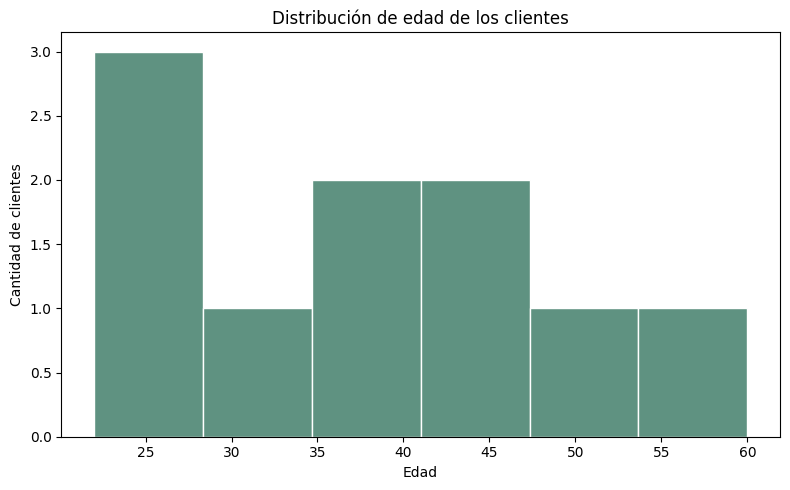

In [6]:
# Histograma de edad
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="edad", bins=6, color="#2a6e57", edgecolor="white")
plt.title("Distribución de edad de los clientes")
plt.xlabel("Edad")
plt.ylabel("Cantidad de clientes")
plt.tight_layout()
plt.show()

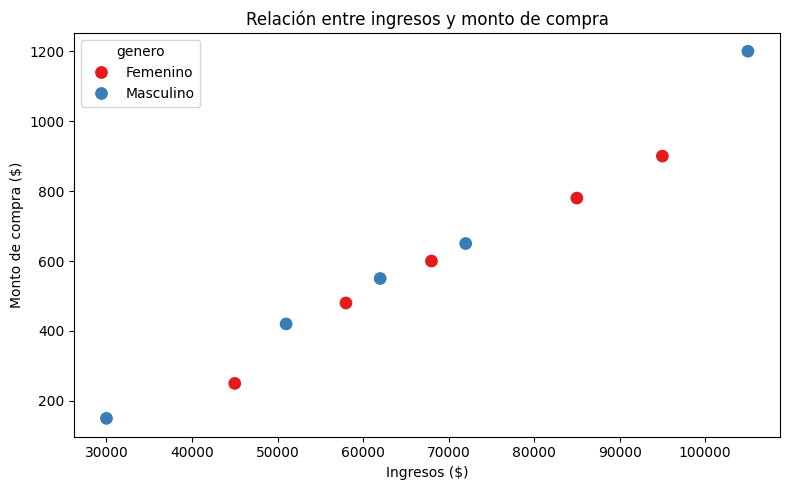

In [7]:
# Scatter plot de ingresos vs monto_compra
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="ingresos", y="monto_compra",
                hue="genero", s=100, palette="Set1")
plt.title("Relación entre ingresos y monto de compra")
plt.xlabel("Ingresos ($)")
plt.ylabel("Monto de compra ($)")
plt.tight_layout()
plt.show()

## Conclusiones

- El dataset contiene **10 clientes** con 6 variables, sin valores faltantes ni duplicados.
- La **media del monto de compra** ($598) es ligeramente superior a la **mediana** ($575), lo que sugiere una distribución levemente asimétrica hacia valores altos.
- De los 10 clientes, **8 son de alto valor** (ingresos mayores a $50.000).
- Entre los clientes de alto valor, los **divorciados** tienen el ingreso promedio más alto ($83.500), seguidos por los **casados** ($80.000) y luego los **solteros** ($54.500).
- El scatter plot evidencia una **correlación positiva fuerte** entre ingresos y monto de compra: a mayor ingreso, mayor gasto. Esta relación es la base para futuras acciones de segmentación comercial.